In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file
df = pd.read_csv("ipl_ball_by_ball.csv")  # change this to your CSV file name
df2 = pd.read_csv("ipl_final_dataset.csv")
df3 = pd.read_csv("ipl_match_by_match.csv")

# # Show basic info
# print("Shape of DataFrame:", df.shape)
# print("\nColumns:\n", df.columns)
# print("\nData Types:\n", df.dtypes)
# print("\nMissing Values:\n", df.isnull().sum())
# print("\nStatistical Summary:\n", df.describe())

# # Show basic info
# print("Shape of DataFrame:", df2.shape)
# print("\nColumns:\n", df2.columns)
# print("\nData Types:\n", df2.dtypes)
# print("\nMissing Values:\n", df2.isnull().sum())
# print("\nStatistical Summary:\n", df2.describe())

# # Show basic info
# print("Shape of DataFrame:", df3.shape)
# print("\nColumns:\n", df3.columns)
# print("\nData Types:\n", df3.dtypes)
# print("\nMissing Values:\n", df3.isnull().sum())
# print("\nStatistical Summary:\n", df3.describe())

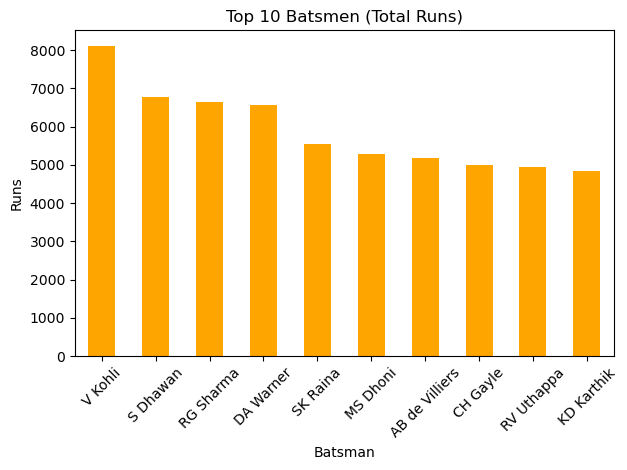

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("ipl_ball_by_ball_revised.csv")

# Remove rows with null batsman or runs_batsman
df = df[df['batsman'].notna() & df['runs_batsman'].notna()]

# Convert runs_batsman to numeric if needed_
df['runs_batsman'] = pd.to_numeric(df['runs_batsman'], errors='coerce')

# Now group and plot
top_batsmen = df.groupby('batsman')['runs_batsman'].sum().sort_values(ascending=False).head(10)

if not top_batsmen.empty:
    top_batsmen.plot(kind='bar', title='Top 10 Batsmen (Total Runs)', ylabel='Runs', xlabel='Batsman', color='orange')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid data for batsman runs!")


In [37]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load the dataset
# df = pd.read_csv("ipl_ball_by_ball_revised.csv")

# # Filter rows where a player was dismissed and the dismissal is credited to the bowler
# valid_wickets = df[df['player_dismissed'].notna() & df['kind'].notna()]

# # List of dismissal types that credit the wicket to the bowler
# bowler_wicket_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

# # Filter only those dismissals
# valid_wickets = valid_wickets[valid_wickets['kind'].isin(bowler_wicket_kinds)]

# # Count number of wickets per bowler
# top_bowlers = valid_wickets['bowler'].value_counts().head(10)

# # Plot the top 10 wicket takers
# if not top_bowlers.empty:
#     top_bowlers.plot(kind='bar', title='Top 10 Wicket-Takers', ylabel='Wickets', xlabel='Bowler', color='purple')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("⚠️ No valid data for bowler wickets!")


KeyError: 'player_dismissed'

In [ ]:
# Runs per over
runs_per_over = df.groupby('over')['runs_total'].sum()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=runs_per_over.index, y=runs_per_over.values, marker='o')
plt.title('Runs per Over (All Matches)')
plt.xlabel('Over')
plt.ylabel('Total Runs')

# Set x-ticks for every over
plt.xticks(ticks=range(0, 20), labels=[str(i) for i in range(1, 21)])

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path with your actual file path
data = pd.read_csv(file_path)

# Replace team names in the relevant columns
data['team1'] = data['team1'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

data['team2'] = data['team2'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'

})

data['winner'] = data['winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

data['toss_winner'] = data['toss_winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})


# Plot 1: Top 15 Most Wins by Teams (Fixed)
plt.figure(figsize=(12, 6))
data['winner'].value_counts().head(15).plot(kind='bar', color='orange')
plt.title('Top 15 Most Wins by Teams')
plt.ylabel('Wins')
plt.xticks(rotation=30, ha='right')  # rotate and right-align
plt.tight_layout()
plt.show()


In [ ]:

matches_played = pd.concat([data['team1'], data['team2']]).value_counts()

# Matches won
matches_won = data['winner'].value_counts()

# Combine into DataFrame
win_rate_df = pd.DataFrame({
    'matches_played': matches_played,
    'matches_won': matches_won
})
win_rate_df.fillna(0, inplace=True)
win_rate_df['win_rate'] = (win_rate_df['matches_won'] / win_rate_df['matches_played']) * 100

# Filter teams with at least 50 matches
win_rate_df_filtered = win_rate_df[win_rate_df['matches_played'] >= 50]

# Top 10 by win rate
top_win_rate = win_rate_df_filtered.sort_values('win_rate', ascending=False).head(10)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=top_win_rate.index, y=top_win_rate['win_rate'], color='mediumseagreen')
plt.title("Top 10 Teams by Win Rate (Min 50 Matches)")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [ ]:
df = pd.read_csv("ipl_match_by_match.csv")

# Venue frequency
df['venue'].value_counts().head(10).plot(kind='barh', title='Top 10 Venues by Match Count', color='green')
plt.xlabel("Match Count")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Match result type count
# df['result'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
# plt.title('Result Type Distribution')
# plt.ylabel('')
# plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ipl_match_by_match.csv")

# Fill NA and categorize
df['result'] = df['result'].fillna('no result')

# Categorize
def simplify_result(result):
    if 'wickets' in result:
        return 'Won by Wickets'
    elif 'runs' in result:
        return 'Won by Runs'
    elif result == 'no result':
        return 'No Result'
    else:
        return 'Other'

df['result_category'] = df['result'].apply(simplify_result)

# Plot pie chart with grouped categories
df['result_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*3,
    colors=['skyblue', 'lightgreen', 'lightcoral'],
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)
plt.title('Result Type Distribution (Grouped)')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Get unique venues and sort them
venue = sorted(df["venue"].dropna().unique())

# Convert to DataFrame
venue_df = pd.DataFrame(venue, columns=["Venue"])

# Save to CSV
venue_df.to_csv("ipl_venue.csv", index=False)


In [ ]:
# Define the mapping of variants to the standardized long names
venue_replacements = {
    # Arun Jaitley
    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",

    # Chinnaswamy
    "M Chinnaswamy Stadium": "M Chinnaswamy Stadium, Bengaluru",

    # Rajiv Gandhi
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",

    # HPCA Dharamsala
    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium, Dharamsala",

    # Sawai Mansingh
    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium, Jaipur",

    # DY Patil
    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy, Mumbai",

    # Eden Gardens
    "Eden Gardens": "Eden Gardens, Kolkata",

    # Punjab Stadium
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",

    # Wankhede
    "Wankhede Stadium": "Wankhede Stadium, Mumbai",

    # Chepauk
    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chepauk, Chennai",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chepauk, Chennai", 

    #Brabourne
    "Brabourne Stadium": "Brabourne Stadium, Mumbai",

    #YSRR Stadium
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",

    #MCA Stadium
    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium, Pune",

    #Arun Jaitley
    "Feroz Shah Kotla":"Arun Jaitley Stadium, Delhi",

    #Narender Modi Stadium
    "Sardar Patel Stadium, Moter": "Narendra Modi Stadium, Ahmedabad", 

    #Sheilk Zayed Stadium
    "Sheikh Zayed Stadium" : "Zayed Cricket Stadium, Abu Dhabi"

}

# Apply the mapping to the DataFrame
df["venue"] = df["venue"].replace(venue_replacements)

venue = sorted(df["venue"].dropna().unique())

# Convert to DataFrame
venue_df = pd.DataFrame(venue, columns=["Venue"])

# Save to CSV
venue_df.to_csv("ipl_venue.csv", index=False)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path with your actual file path
data = pd.read_csv(file_path)

# Extract the season from the date
data['season'] = pd.to_datetime(data['date']).dt.year

# Create a new column to check if the toss winner won the match
data['toss_winner_wins'] = data['toss_winner'] == data['winner']

# Group by season and calculate total matches and matches won by toss winners
season_stats = data.groupby(['season', 'toss_winner_wins']).size().unstack(fill_value=0)

# Calculate percentage of matches won by toss winners
season_percentage = (season_stats[True] / (season_stats[True] + season_stats[False])) * 100

# Display the percentage for better understanding
# print("Season-wise Percentage of Toss Winner Wins:\n", season_percentage)

# Create a bar plot for visualization of percentages
plt.figure(figsize=(12, 6))
season_percentage.plot(kind='bar', color='orange')
plt.title('Percentage of Matches Won by Toss Winners (Season-wise)')
plt.ylabel('Winning Percentage (%)')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.axhline(y=50, color='red', linestyle='--', label='50% Threshold')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path if needed
data = pd.read_csv(file_path)

# Create a new column to check if the toss winner won the match
data['toss_winner_wins'] = data['toss_winner'] == data['winner']

# Group by venue and calculate total matches and matches won by toss winners
venue_stats = data.groupby(['venue', 'toss_winner_wins']).size().unstack(fill_value=0)

# Calculate total matches at each venue
venue_stats['total_matches'] = venue_stats[True] + venue_stats[False]

# Filter venues with at least 10 matches
filtered_stats = venue_stats[venue_stats['total_matches'] >= 10]

# Calculate percentage of matches won by toss winners at filtered venues
venue_percentage = (filtered_stats[True] / filtered_stats['total_matches']) * 100

# Sort by percentage for better visualization
venue_percentage = venue_percentage.sort_values(ascending=False)

# Create a bar plot
plt.figure(figsize=(14, 8))
venue_percentage.plot(kind='barh', color='skyblue')
plt.title('Percentage of Matches Won by Toss Winners (Venues with ≥10 Matches)')
plt.xlabel('Winning Percentage (%)')
plt.ylabel('Venue')
plt.axvline(x=50, color='red', linestyle='--', label='50% Threshold')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'ipl_match_by_match.csv'
data = pd.read_csv(file_path)

# Create a new column to check if the toss winner won the match
data['toss_winner_wins'] = data['toss_winner'] == data['winner']

# Group by venue and calculate total matches and matches won by toss winners
venue_stats = data.groupby(['venue', 'toss_winner_wins']).size().unstack(fill_value=0)

# Calculate total matches at each venue
venue_stats['total_matches'] = venue_stats[True] + venue_stats[False]

# Filter venues with at least 10 matches
filtered_stats = venue_stats[venue_stats['total_matches'] >= 20]

# Calculate percentage of matches won by toss winners at filtered venues
venue_percentage = (filtered_stats[True] / filtered_stats['total_matches']) * 100
venue_percentage = venue_percentage.sort_values(ascending=True)  # For better horizontal layout

# Plotting
plt.figure(figsize=(14, 10))
bars = plt.barh(venue_percentage.index, venue_percentage.values, color='#4FC3F7', edgecolor='black')

# Add grid, title and labels
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% Threshold')
plt.title('Toss Winner Match Win Percentage (Venues with ≥20 Matches)', fontsize=16, weight='bold')
plt.xlabel('Winning Percentage (%)', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.xlim(0, 100)
plt.legend()

# Add percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=10)

# Final layout tweaks
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path with your actual file path
data = pd.read_csv(file_path)

# Create a new column to check if toss winner won the match
data['toss_winner_wins'] = data['toss_winner'] == data['winner']

# Calculate the number of matches won by toss winners and not won
toss_winner_stats = data['toss_winner_wins'].value_counts()

# Display the counts
# print("Toss Winner Statistics:\n", toss_winner_stats)

# Create a bar plot for visualization
plt.figure(figsize=(8, 5))
toss_winner_stats.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Did Toss Winner Also Win the Match?')
plt.xticks(
    ticks=[0, 1],
    labels=['Toss Winner Won', 'Toss Winner Lost'],
    rotation=0
)
plt.ylabel('Number of Matches')
plt.xlabel('Outcome')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path with your actual file path
data = pd.read_csv(file_path)

# Extract the season from the date
data['season'] = pd.to_datetime(data['date']).dt.year

# Create a new column to check if toss winner won the match
data['toss_winner_wins'] = data['toss_winner'] == data['winner']

# Group by season and count matches won/lost by toss winners
season_stats = data.groupby(['season', 'toss_winner_wins']).size().unstack(fill_value=0)

# Create a bar plot for visualization
season_stats.plot(kind='bar', stacked=True, color=['lightcoral', 'skyblue'], figsize=(12, 6))
plt.title('Season-wise Toss Winner vs Match Winner')
plt.ylabel('Number of Matches')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.legend(title='Toss Winner Outcome', labels=['Lost', 'Won'])
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path with your actual file path
data = pd.read_csv(file_path)

# Replace team names in the relevant columns
data['team1'] = data['team1'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

data['team2'] = data['team2'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'

})

data['winner'] = data['winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

data['toss_winner'] = data['toss_winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})


# Count chasing and defending wins
chasing_stats = data[data['toss_decision'] == 'field']['winner'].value_counts()
defending_stats = data[data['toss_decision'] == 'bat']['winner'].value_counts()

# Combine into one DataFrame
win_df = pd.DataFrame({
    'Chasing Wins': chasing_stats,
    'Defending Wins': defending_stats
}).fillna(0)

# Sort by total wins
win_df['Total'] = win_df['Chasing Wins'] + win_df['Defending Wins']
win_df = win_df.sort_values('Total', ascending=False)

# Plot side-by-side bars
plt.figure(figsize=(14, 7))
bar_width = 0.4
teams = win_df.index
x = np.arange(len(teams))

plt.bar(x - bar_width/2, win_df['Chasing Wins'], width=bar_width, color='skyblue', label='Chasing Wins')
plt.bar(x + bar_width/2, win_df['Defending Wins'], width=bar_width, color='lightcoral', label='Defending Wins')

# Add value labels
for i in range(len(teams)):
    plt.text(x[i] - bar_width/2, win_df['Chasing Wins'].iloc[i] + 1, int(win_df['Chasing Wins'].iloc[i]), ha='center', fontsize=8)
    plt.text(x[i] + bar_width/2, win_df['Defending Wins'].iloc[i] + 1, int(win_df['Defending Wins'].iloc[i]), ha='center', fontsize=8)

# Final plot tweaks
plt.xticks(x, teams, rotation=45, ha='right')
plt.ylabel('Number of Wins')
plt.xlabel('Teams')
plt.title('Team Strength: Chasing vs Defending')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:

# Count chasing and defending wins
chasing_stats = data[data['toss_decision'] == 'field']['winner'].value_counts()
defending_stats = data[data['toss_decision'] == 'bat']['winner'].value_counts()

# Combine into one DataFrame
win_df = pd.DataFrame({
    'Chasing Wins': chasing_stats,
    'Defending Wins': defending_stats
}).fillna(0)

# Total wins = chasing + defending
win_df['Total Wins'] = win_df['Chasing Wins'] + win_df['Defending Wins']

# Calculate chasing win percentage out of total wins
win_df['Chasing Win %'] = (win_df['Chasing Wins'] / win_df['Total Wins']) * 100

# Sort by chasing win %
win_df = win_df.sort_values('Chasing Win %', ascending=False)

# Plot
plt.figure(figsize=(14, 7))
teams = win_df.index
x = np.arange(len(teams))
bar_color = 'skyblue'

plt.bar(x, win_df['Chasing Win %'], color=bar_color, alpha=0.8)

# Add value labels
for i, val in enumerate(win_df['Chasing Win %']):
    plt.text(x[i], val + 1, f'{val:.1f}%', ha='center', fontsize=8)

# Final touches
plt.xticks(x, teams, rotation=45, ha='right')
plt.ylabel('Chasing Win % (out of Total Wins)')
plt.xlabel('Teams')
plt.title('Team Chasing Efficiency: % of Wins While Chasing')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


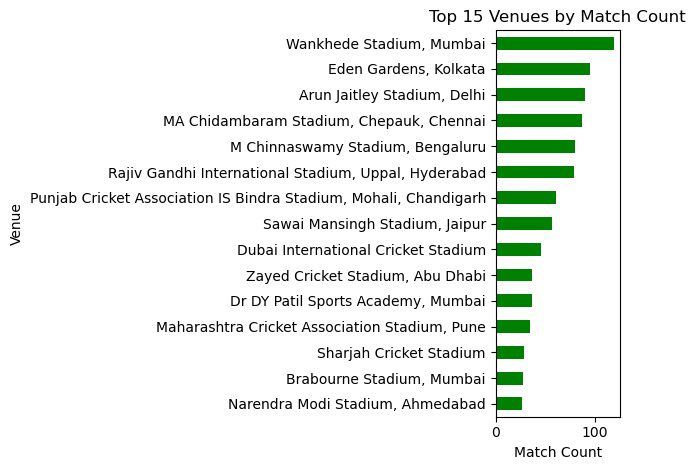

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path with your actual file path
df = pd.read_csv(file_path)
venue_replacements = {
    # Arun Jaitley
    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",

    # Chinnaswamy
    "M Chinnaswamy Stadium": "M Chinnaswamy Stadium, Bengaluru",

    # Rajiv Gandhi
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",

    # HPCA Dharamsala
    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium, Dharamsala",

    # Sawai Mansingh
    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium, Jaipur",

    # DY Patil
    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy, Mumbai",

    # Eden Gardens
    "Eden Gardens": "Eden Gardens, Kolkata",

    # Punjab Stadium
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",

    # Wankhede
    "Wankhede Stadium": "Wankhede Stadium, Mumbai",

    # Chepauk
    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chepauk, Chennai",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chepauk, Chennai", 

    #Brabourne
    "Brabourne Stadium": "Brabourne Stadium, Mumbai",

    #YSRR Stadium
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",

    #MCA Stadium
    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium, Pune",

    #Arun Jaitley
    "Feroz Shah Kotla":"Arun Jaitley Stadium, Delhi",

    #Narender Modi Stadium
    "Sardar Patel Stadium, Moter": "Narendra Modi Stadium, Ahmedabad", 

    #Sheilk Zayed Stadium
    "Sheikh Zayed Stadium" : "Zayed Cricket Stadium, Abu Dhabi"

}

# Apply the mapping to the DataFrame
df["venue"] = df["venue"].replace(venue_replacements)

venue = sorted(df["venue"].dropna().unique())

df['venue'].value_counts().head(15).plot(kind='barh', title='Top 15 Venues by Match Count', color='green')
plt.xlabel("Match Count")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

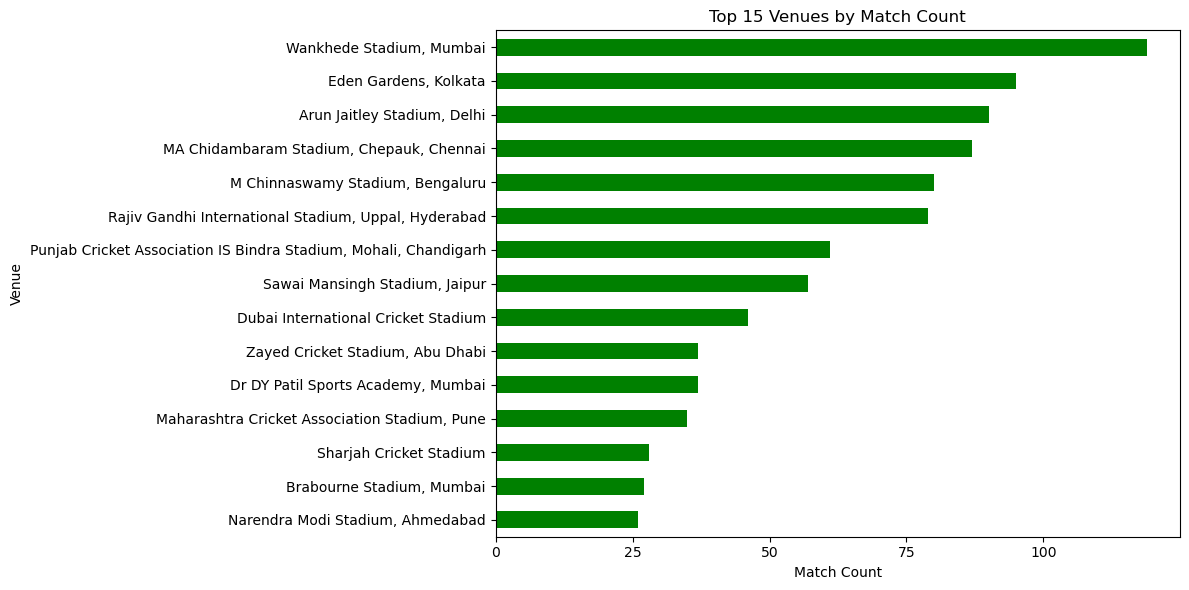

In [42]:
#statium anolonomy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Load the CSV file
file_path = 'ipl_match_by_match.csv'  # Update this path if needed
df = pd.read_csv(file_path)

# Venue replacement dictionary
venue_replacements = {
    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",
    "Feroz Shah Kotla": "Arun Jaitley Stadium, Delhi",
    "M Chinnaswamy Stadium": "M Chinnaswamy Stadium, Bengaluru",
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium, Dharamsala",
    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium, Jaipur",
    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy, Mumbai",
    "Eden Gardens": "Eden Gardens, Kolkata",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Wankhede Stadium": "Wankhede Stadium, Mumbai",
    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chepauk, Chennai",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chepauk, Chennai", 
    "Brabourne Stadium": "Brabourne Stadium, Mumbai",
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",
    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium, Pune",
    "Sardar Patel Stadium, Moter": "Narendra Modi Stadium, Ahmedabad", 
    "Sheikh Zayed Stadium": "Zayed Cricket Stadium, Abu Dhabi"
}

# Apply venue mapping
df["venue"] = df["venue"].replace(venue_replacements)

# Set figure size to increase x-axis length (width x height in inches)
plt.figure(figsize=(12, 6))  # Wider figure

# Plot top 15 venues
df['venue'].value_counts().head(15).plot(kind='barh', title='Top 15 Venues by Match Count', color='green')

# Axis labels and ticks
plt.xlabel("Match Count")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_locator(MultipleLocator(25))

# Show plot
plt.tight_layout()
plt.show()


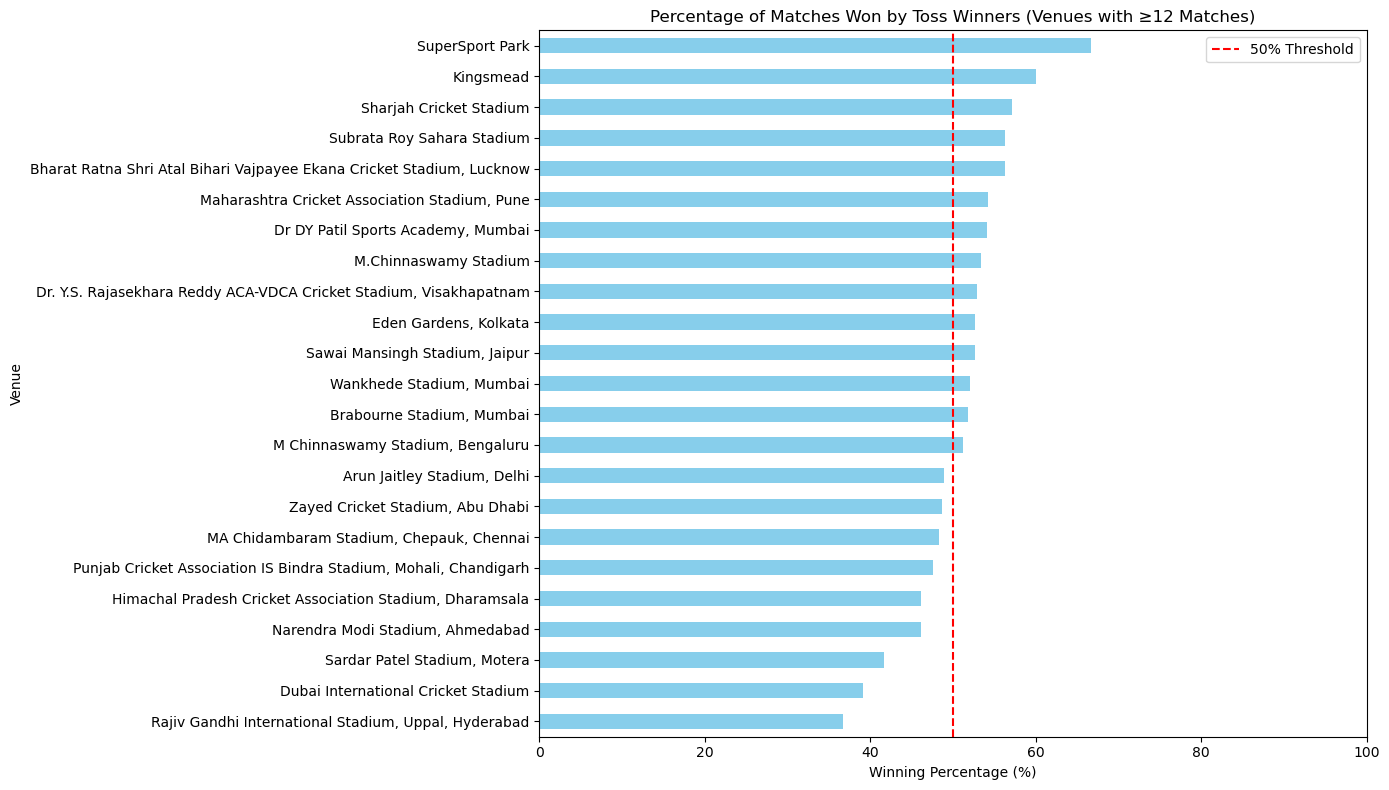

In [46]:
df['toss_winner_wins'] = df['toss_winner'] == df['winner']

# Group by venue and calculate total matches and matches won by toss winners
venue_stats = df.groupby(['venue', 'toss_winner_wins']).size().unstack(fill_value=0)

# Calculate total matches at each venue
venue_stats['total_matches'] = venue_stats[True] + venue_stats[False]

# Filter venues with at least 10 matches
filtered_stats = venue_stats[venue_stats['total_matches'] >= 12]

# Calculate percentage of matches won by toss winners at filtered venues
venue_percentage = (filtered_stats[True] / filtered_stats['total_matches']) * 100

# Sort by percentage for better visualization
venue_percentage = venue_percentage.sort_values(ascending=True)

# Create a bar plot
plt.figure(figsize=(14, 8))
venue_percentage.plot(kind='barh', color='skyblue')
plt.title('Percentage of Matches Won by Toss Winners (Venues with ≥12 Matches)')
plt.xlabel('Winning Percentage (%)')
plt.ylabel('Venue')
plt.axvline(x=50, color='red', linestyle='--', label='50% Threshold')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# # Filter chasing and defending decisions
# chasing = data[data['toss_decision'] == 'field']
# defending = data[data['toss_decision'] == 'bat']

# # Count matches where team won while chasing
# chasing_wins = chasing[chasing['winner'] == chasing['toss_winner']].shape[0]

# # Count matches where team won while defending
# defending_wins = defending[defending['winner'] == defending['toss_winner']].shape[0]

# # Total matches with clear chase/defend wins
# total = chasing_wins + defending_wins

# # Percentages
# chasing_win_pct = (chasing_wins / total) * 100
# defending_win_pct = (defending_wins / total) * 100

# # Print results
# print(f"Chasing Win %: {chasing_win_pct:.2f}%")
# print(f"Defending Win %: {defending_win_pct:.2f}%")
